# Value at Risk (VaR) Model
## A Quantitative Risk Analysis of a 5-Stock Portfolio
### Cynthia Wanjiru | WashU MSFQ 2026

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats


## Step 1: Download historical stock data
tickers = ( 'AAPL' , 'JPM' , 'XOM' , 'JNJ' , 'SPY' )
weights = ( 0.2, 0.2, 0.2, 0.2, 0.2)
start_date = '2020-01-01'
end_date = '2024-12-31'
data = yf.download(tickers, start=start_date, end=end_date)['Close']


In [2]:
tickers = ['AAPL', 'JPM', 'XOM', 'JNJ', 'SPY']
weights = [0.2, 0.2, 0.2, 0.2, 0.2]
start_date = '2020-01-01'
end_date = '2024-12-31'
data = yf.download(tickers, start=start_date, end=end_date)['Close']

[*********************100%***********************]  5 of 5 completed


In [3]:
returns =data.pct_change() .dropna()
returns.head()

Ticker,AAPL,JNJ,JPM,SPY,XOM
Date,,,,,
2020-01-03,-0.009722,-0.011578,-0.013196,-0.007573,-0.008040
2020-01-06,0.007968,-0.001248,-0.000795,0.003815,0.007678
2020-01-07,-0.004703,0.006107,-0.017001,-0.002812,-0.008184
2020-01-08,0.016086,-0.000138,0.007801,0.005330,-0.015080
2020-01-09,0.021241,0.002967,0.003651,0.006780,0.007656


In [4]:
portfolio_returns = returns.dot(weights)
print (len(portfolio_returns))

1256


In [5]:
## Step 2: Historical Simulation VaR
Confidence_level= 0.95
historical_VaR= np.percentile(portfolio_returns, (1-Confidence_level) * 100)
print (historical_VaR)


-0.018034368355771005


In [6]:
### Step 3: Parametric VaR
mean_return= portfolio_returns.mean()
std_return= portfolio_returns.std()
Parametric_VaR= mean_return - (stats.norm.ppf(Confidence_level) * std_return)
print (Parametric_VaR)

-0.021430327132169674


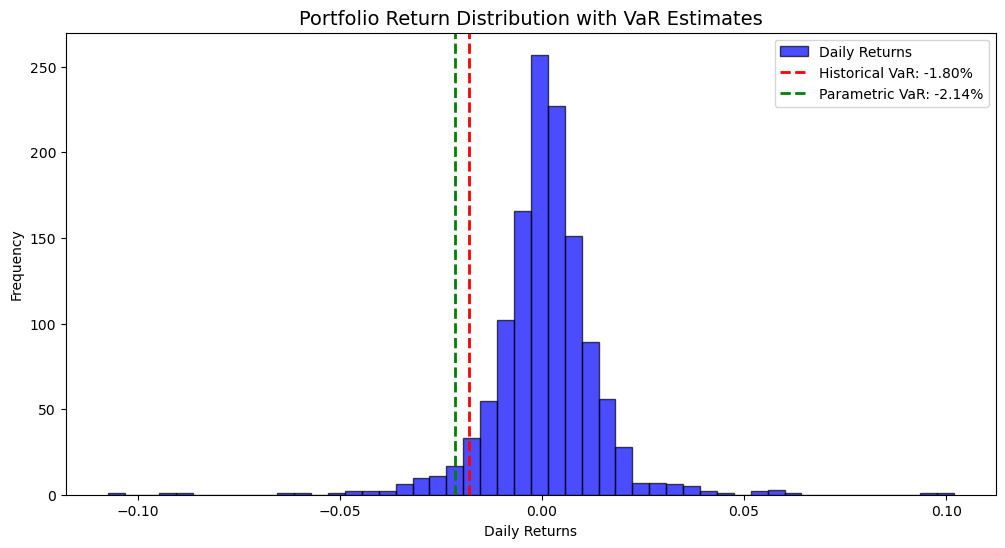

In [7]:
### Step 4: Visualization
plt.figure(figsize=(12, 6))
plt.hist(portfolio_returns, bins=50, alpha=0.7, color='blue', edgecolor='black', label='Daily Returns')
plt.axvline(historical_VaR, color='red', linestyle='--', linewidth=2, label=f'Historical VaR: {historical_VaR*100:.2f}%')
plt.axvline(Parametric_VaR, color='green', linestyle='--', linewidth=2, label=f'Parametric VaR: {Parametric_VaR*100:.2f}%')
plt.title('Portfolio Return Distribution with VaR Estimates', fontsize=14)
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [8]:
# Final Comparison Summary
print("=" * 50)
print("PORTFOLIO VAR ANALYSIS - SUMMARY")
print("=" * 50)
print(f"Portfolio: AAPL, JNJ, JPM, SPY, XOM")
print(f"Equal Weights: 20% each")
print(f"Time Period: 2020 - 2024")
print(f"Confidence Level: 95%")
print(f"Trading Days Analyzed: {len(portfolio_returns)}")
print("-" * 50)
print(f"Historical Simulation VaR: {historical_VaR*100:.2f}%")
print(f"Parametric VaR:            {Parametric_VaR*100:.2f}%")
print("-" * 50)
print(f"Difference: {abs(Parametric_VaR - historical_VaR)*100:.2f}%")
print("=" * 50)

PORTFOLIO VAR ANALYSIS - SUMMARY
Portfolio: AAPL, JNJ, JPM, SPY, XOM
Equal Weights: 20% each
Time Period: 2020 - 2024
Confidence Level: 95%
Trading Days Analyzed: 1256
--------------------------------------------------
Historical Simulation VaR: -1.80%
Parametric VaR:            -2.14%
--------------------------------------------------
Difference: 0.34%


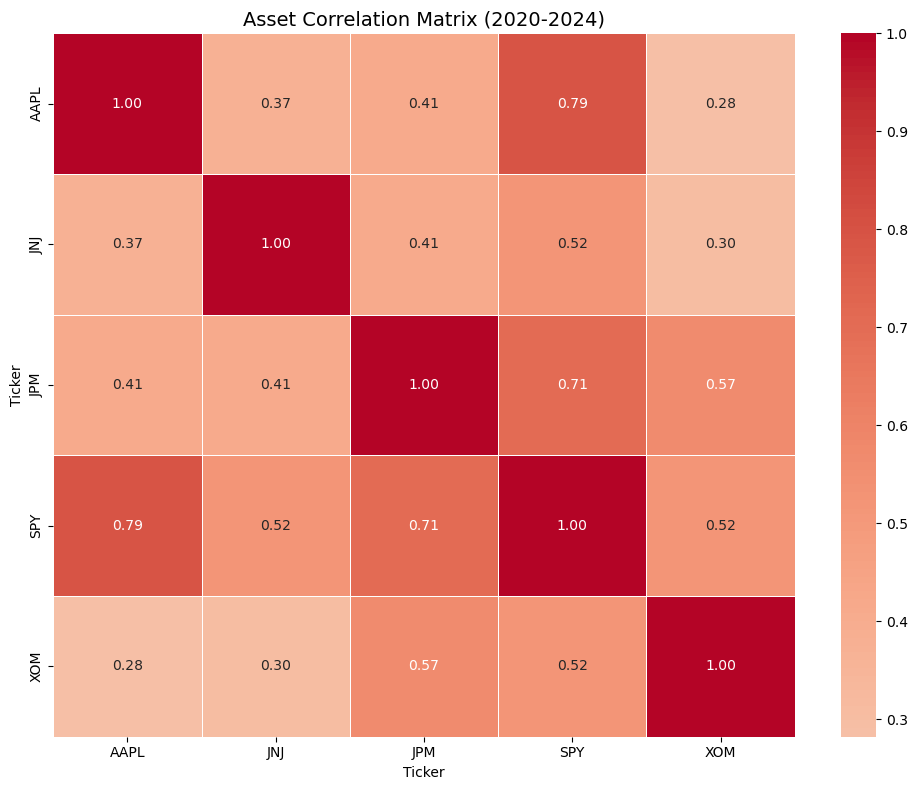


Correlation Matrix:
Ticker  AAPL   JNJ   JPM   SPY   XOM
Ticker                              
AAPL    1.00  0.37  0.41  0.79  0.28
JNJ     0.37  1.00  0.41  0.52  0.30
JPM     0.41  0.41  1.00  0.71  0.57
SPY     0.79  0.52  0.71  1.00  0.52
XOM     0.28  0.30  0.57  0.52  1.00


In [11]:
import seaborn as sns

# Correlation Matrix
correlation_matrix = returns.corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            linewidths=0.5)
plt.title('Asset Correlation Matrix (2020-2024)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(2))

## Correlation Analysis

The heatmap reveals important diversification dynamics within the portfolio. 
AAPL and SPY show the highest correlation at 0.79, which is expected given 
that AAPL constitutes a significant portion of the S&P 500 index. Similarly, 
JPM and SPY move closely together at 0.71, reflecting the broad market 
sensitivity of large cap financials.

The best diversification in the portfolio comes from JNJ and XOM, which 
show the lowest pairwise correlation at 0.30. This makes intuitive sense 
as healthcare and energy are driven by completely different factors. 
JNJ is defensive, driven by drug pipelines and regulatory approvals. 
XOM is cyclical, driven by oil prices and global energy demand.

The practical implication for VaR is that the portfolio is not as 
diversified as five stocks might suggest. AAPL, SPY and JPM form a 
highly correlated cluster that moves together, meaning a broad market 
selloff would hit all three simultaneously. The genuine diversification 
comes from JNJ and XOM acting as independent return streams. This 
partially explains why the Historical Simulation VaR and Parametric 
VaR diverge — correlation structure in real markets is more complex 
than any single number captures.

## CVaR (Conditional Value at Risk) — Expected Shortfall

VaR tells us the maximum loss at a given confidence level. But it does 
not tell us how bad losses get beyond that threshold. CVaR — also known 
as Expected Shortfall — answers that question by averaging all losses 
that exceed the VaR threshold. Regulators have been moving toward CVaR 
since Basel III precisely because it captures tail risk that VaR ignores.

In [13]:
# CVaR - Historical
confidence_level = 0.95
VaR_threshold = np.percentile(portfolio_returns, (1 - confidence_level) * 100)
CVaR_historical = portfolio_returns[portfolio_returns <= VaR_threshold].mean()

# CVaR - Parametric
CVaR_parametric = mean_return - (stats.norm.pdf(stats.norm.ppf(1 - confidence_level)) / 
                  (1 - confidence_level)) * std_return

print("=" * 50)
print("CVaR ANALYSIS — SUMMARY")
print("=" * 50)
print(f"Historical VaR (95%):    {historical_VaR*100:.2f}%")
print(f"Historical CVaR (95%):   {CVaR_historical*100:.2f}%")
print("-" * 50)
print(f"Parametric VaR (95%):    {Parametric_VaR*100:.2f}%")
print(f"Parametric CVaR (95%):   {CVaR_parametric*100:.2f}%")
print("=" * 50)

CVaR ANALYSIS — SUMMARY
Historical VaR (95%):    -1.80%
Historical CVaR (95%):   -3.16%
--------------------------------------------------
Parametric VaR (95%):    -2.14%
Parametric CVaR (95%):   -2.71%


## CVaR Interpretation

Historical CVaR of -3.16% reveals that once losses breach the VaR 
threshold, the average loss is nearly double the VaR estimate of -1.80%. 
This gap captures the tail risk that VaR alone ignores, precisely why 
regulators moved toward Expected Shortfall under Basel III.